# TP2 — Curación de datos y definición de mercado

**Diplomatura en Ciencia de Datos · Mentoría ID90Travel 2026**

Este práctico transforma las búsquedas hoteleras crudas en un dataset limpio y comparable, y define las reglas estadísticas que usa el detector de ofertas del TP3.

El trabajo tiene dos etapas:
1. **Curación y estandarización**: auditoría de integridad de los datos, normalización de precios a USD por habitación-noche-persona, mapping geográfico de los más de 26.000 nombres de ciudad crudos y construcción de las variables de contexto de reserva.
2. **Definición de mercado y análisis de precios**: definición operativa de "mercado hotelero", verificación de su masa estadística y comparación empírica de cinco estadísticos de detección de ofertas frente al Z-score del docente.

---

## Contenidos del notebook

1. [Carga de datos y entorno](#1-carga-de-datos-y-entorno)
2. [Auditoría de calidad, limpieza y precio estándar](#2-auditoría-de-calidad-limpieza-y-precio-estándar)
3. [Variables de contexto temporal y duración](#3-variables-de-contexto-temporal-y-duración)
4. [Mapping geográfico y categoría de hotel (`price_bucket`)](#4-mapping-geográfico-y-categoría-de-hotel-price_bucket)
5. [La decisión central: definición de mercado y masa crítica](#5-la-decisión-central-definición-de-mercado-y-masa-crítica)
6. [Distribución de precios dentro de cada mercado](#6-distribución-de-precios-dentro-de-cada-mercado)
7. [Comparativa de estadísticos: evaluando alternativas de detección](#7-comparativa-de-estadísticos-evaluando-alternativas-de-detección)
8. [Decisiones metodológicas para el TP3](#8-decisiones-metodológicas-para-el-tp3)

In [1]:
import os
import sys
from pathlib import Path

# Resolver ruta raíz del repositorio
_current_dir = Path(".").resolve()
for p in [_current_dir, _current_dir.parent, _current_dir.parent.parent]:
    if (p / "config.py").exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        ROOT_DIR = p
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
import auxiliary_functions as af

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

print(f"Directorio raíz: {ROOT_DIR}")

Directorio raíz: /home/francisco/Documents/Github/mentoria-id90/TP2_entrega


## 1. Carga de datos y entorno

Se trabaja sobre una muestra aleatoria de **300.000 búsquedas** (`sample_data_300k.csv.gz`, seed=42) para ejecutar rápido sin perder representatividad. Para procesar los 5.1 millones de registros históricos (2024 + 2025), activar la variable de entorno `USE_FULL_HISTORICALS=1`.

In [2]:
data_dir = ROOT_DIR / "data"
mapping_df = af.load_destination_mapping(data_dir / "destination_with_nearest.csv")

sample_gz = data_dir / "sample_data_300k.csv.gz"
hist_files = sorted(list(data_dir.glob("datos_historicos_*.csv")))
use_full = os.environ.get("USE_FULL_HISTORICALS", "0") == "1"

if use_full and hist_files:
    print(f"Cargando archivos históricos completos: {[f.name for f in hist_files]}")
    df_raw = af.load_all_historicals()
    fuente = "Históricos completos (5.1M filas)"
elif sample_gz.exists():
    print(f"Cargando muestra representativa: {sample_gz.name}")
    df_raw = pd.read_csv(
        sample_gz,
        dtype={"city": str, "state": str, "country": str, "country_code": str},
        low_memory=False
    )
    fuente = "Muestra 300k (seed=42)"
elif hist_files:
    print(f"Fallback a históricos completos: {[f.name for f in hist_files]}")
    df_raw = af.load_all_historicals()
    fuente = "Históricos completos"
else:
    raise FileNotFoundError(f"No hay datos en {data_dir}")

print(f"Total registros cargados ({fuente}): {len(df_raw):,}")

2026-09-03 20:22:49,180 - INFO - Mapping cargado: 15,988 registros


2026-09-03 20:22:49,182 - INFO -   Destinos canónicos únicos: 2,584


Cargando muestra representativa: sample_data_300k.csv.gz


Total registros cargados (Muestra 300k (seed=42)): 300,000


## 2. Auditoría de calidad, limpieza y precio estándar

Un precio no se puede comparar si no mide lo mismo: un paquete familiar de 7 noches en dos habitaciones no equivale a una noche individual.

La auditoría ataca cuatro problemas:
1. **Denominadores en cero**: búsquedas con 0 personas, 0 habitaciones o noches $\le 0$ romperían la división.
2. **Noches inconsistentes**: estadías de más de 30 noches (alquileres mensuales o errores de carga).
3. **Precios inválidos**: valores $\le 0$ o superiores a 50.000 USD.
4. **Estandarización**:
   $$\text{price\_std} = \frac{\text{avg\_price\_average}}{\text{nights} \times \text{number\_of\_rooms} \times (\text{adults} + \text{kids})}$$

Para que los valores extremos no distorsionen promedios y desvíos, se winsoriza la cola derecha al **percentil 99.9**.

In [3]:
# 1. Auditoría y validación
df_valid = af.validate_data(df_raw)
n_validos = len(df_valid)

# 2. Estandarización y winsorización al p99.9
df_std = af.standardize_prices(df_valid)
n_std = len(df_std)

# Resumen del embudo de limpieza
funnel = pd.DataFrame({
    "etapa": ["Datos crudos (raw)", "Denominadores válidos y noches <= 30", "Precios válidos (> 0) y winsorizados"],
    "filas": [len(df_raw), n_validos, n_std],
    "pct_retenido": [
        100.0,
        100.0 * n_validos / len(df_raw),
        100.0 * n_std / len(df_raw)
    ]
})
print("Embudo de curación del dataset:")
print(funnel.to_string(index=False))

# Auditoría residual: se comprueba la ausencia de valores inválidos
auditoria = {
    "precio_std <= 0": (df_std["avg_price_average_std"] <= 0).sum(),
    "noches <= 0": (df_std["nights"] <= 0).sum(),
    "habitaciones <= 0": (df_std["number_of_rooms"] <= 0).sum(),
    "ocupacion <= 0": ((df_std["number_of_adults"] + df_std["number_of_kids"]) <= 0).sum(),
    "noches > 30": (df_std["nights"] > 30).sum(),
}
print("\nAuditoría residual en df_std:")
for k, v in auditoria.items():
    print(f"  {k}: {v:,}")

p999 = df_std["avg_price_average_std"].quantile(0.999)
print(f"\nRango de price_std resultante: [{df_std['avg_price_average_std'].min():.2f}, {df_std['avg_price_average_std'].max():.2f}] USD")
print(f"Corte superior de winsorización (percentil 99.9): {p999:.2f} USD")

2026-09-03 20:22:50,019 - WARNING - Registros eliminados por datos inválidos u outliers extremos: 42 (0.01%)


2026-09-03 20:22:50,019 - INFO - Registros válidos: 299,958 (100.0%)


2026-09-03 20:22:50,039 - WARNING -   min_price_low_std: 193 registros con precio <= 0 serán eliminados


2026-09-03 20:22:50,156 - WARNING -   avg_price_average_std: 300 registros winsorizados al percentil 99.9 (1416.27)


2026-09-03 20:22:50,158 - INFO - ✓ Precios estandarizados: 299,765 registros


Embudo de curación del dataset:
                               etapa  filas  pct_retenido
                  Datos crudos (raw) 300000    100.000000
Denominadores válidos y noches <= 30 299958     99.986000
Precios válidos (> 0) y winsorizados 299765     99.921667

Auditoría residual en df_std:
  precio_std <= 0: 0
  noches <= 0: 0
  habitaciones <= 0: 0
  ocupacion <= 0: 0
  noches > 30: 0

Rango de price_std resultante: [0.02, 1416.27] USD
Corte superior de winsorización (percentil 99.9): 1416.00 USD


## 3. Variables de contexto temporal y duración

El TP1 mostró que comparar una noche de temporada baja contra un fin de semana de temporada alta distorsiona cualquier detección. Para segmentar calendario y estadía se construyen:
- `day_of_week`: día de check-in (0=Lunes, 6=Domingo).
- `month`: mes de check-in; captura la estacionalidad anual.
- `week_in_month`: semana 1 a 4 del mes; captura las quincenas.
- `year`: año de la búsqueda (2024 / 2025).
- `stay_duration`: **corta** (1-2 noches), **media** (3-5) o **larga** (>5).
- `price_std`: precio estandarizado, USD por habitación-noche-persona.

In [4]:
df_curated = df_std.copy()
df_curated["date_start"] = pd.to_datetime(df_curated["date_start"])
df_curated["date_end"] = pd.to_datetime(df_curated["date_end"])

df_curated["day_of_week"] = df_curated["date_start"].dt.dayofweek
df_curated["month"] = df_curated["date_start"].dt.month
df_curated["year"] = df_curated["date_start"].dt.year

# 4 semanas por mes: días 1-7, 8-15, 16-22, 23-fin
days = df_curated["date_start"].dt.day.values
w = np.ones(len(days), dtype=int)
w[(days >= 8) & (days <= 15)] = 2
w[(days >= 16) & (days <= 22)] = 3
w[days >= 23] = 4
df_curated["week_in_month"] = w

df_curated["stay_duration"] = np.where(
    df_curated["nights"] <= 2, "corta",
    np.where(df_curated["nights"] <= 5, "media", "larga")
)
df_curated["price_std"] = df_curated["avg_price_average_std"]

features_info = pd.DataFrame({
    "feature": ["price_std", "day_of_week", "month", "week_in_month", "year", "stay_duration"],
    "tipo": ["continua", "ordinal (0-6)", "ordinal (1-12)", "ordinal (1-4)", "ordinal", "categórica"],
    "descripción": [
        "Precio por habitación-noche-persona (variable objetivo)",
        "Día de la semana de check-in",
        "Mes de check-in",
        "Semana del mes (días 1-7, 8-15, 16-22, 23-fin)",
        "Año de la búsqueda",
        "Duración de viaje: corta (1-2n), media (3-5n), larga (>5n)"
    ]
})
print("Variables de contexto temporales:")
print(features_info.to_string(index=False))

Variables de contexto temporales:
      feature           tipo                                                descripción
    price_std       continua    Precio por habitación-noche-persona (variable objetivo)
  day_of_week  ordinal (0-6)                               Día de la semana de check-in
        month ordinal (1-12)                                            Mes de check-in
week_in_month  ordinal (1-4)             Semana del mes (días 1-7, 8-15, 16-22, 23-fin)
         year        ordinal                                         Año de la búsqueda
stay_duration     categórica Duración de viaje: corta (1-2n), media (3-5n), larga (>5n)


## 4. Mapping geográfico y categoría de hotel (`price_bucket`)

Los datos crudos traen más de 26.000 nombres de ciudad dispersos: abreviaciones, errores de tipeo y divisiones administrativas menores.

1. **Mapping a destinos canónicos**: `destination_with_nearest.csv` consolida ciudades satélite en su polo turístico principal.
2. **Trazabilidad**: cada fila registra el nivel de matching que la resolvió (`cc_state_code_city`, `cc_country_city`, etc.) o queda como `no_match`.
3. **Categoría de hotel proxy (`price_bucket`)**: sin estrellas ni marcas en el dataset, cada observación se clasifica con los percentiles 25 y 75 de precio de su destino:
   - `low`: precio $\le p_{25}$
   - `medium`: $p_{25} < \text{precio} < p_{75}$
   - `high`: precio $\ge p_{75}$

In [5]:
# 1. Aplicar mapping de destinos
df = af.apply_destination_mapping(df_curated, mapping_df)

total_rows = len(df)
mapped_rows = df["is_mapped"].sum()
total_dem = df["count_repeated"].sum()
mapped_dem = df.loc[df["is_mapped"], "count_repeated"].sum()

geo_cols = ["country_code", "country", "state", "city"]
raw_geo = df[geo_cols].drop_duplicates()
mapped_geo = df.loc[df["is_mapped"], geo_cols].drop_duplicates()

mapping_summary = pd.DataFrame({
    "métrica": ["Filas totales", "Demanda ponderada (búsquedas)", "Geografías únicas (ciudad-estado-país)"],
    "total": [total_rows, total_dem, len(raw_geo)],
    "mapeadas": [mapped_rows, mapped_dem, len(mapped_geo)],
    "pct_cubierto": [
        100.0 * mapped_rows / total_rows,
        100.0 * mapped_dem / total_dem,
        100.0 * len(mapped_geo) / len(raw_geo)
    ]
})
print("Cobertura del mapping de destinos:")
print(mapping_summary.to_string(index=False))

# Distribución por nivel de matching
if "match_level" in df.columns:
    levels = df["match_level"].value_counts().reset_index()
    levels.columns = ["match_level", "filas"]
    levels["pct"] = (100.0 * levels["filas"] / total_rows).round(2)
    print("\nDistribución por match_level:")
    print(levels.to_string(index=False))

    # Top ciudades no mapeadas: se examinan las razones por las que quedan fuera
    unmapped = (
        df.loc[df["match_level"] == "no_match"]
        .groupby(geo_cols, dropna=False)
        .agg(demanda=("count_repeated", "sum"), filas=("count_repeated", "size"))
        .sort_values("demanda", ascending=False)
        .head(6)
        .reset_index()
    )
    print("\nTop 6 geografías sin mapear por volumen de demanda:")
    print(unmapped.to_string(index=False))

# 2. Categoría de hotel proxy: asignación de price_bucket por destino
price_dist = af.calculate_price_distribution_by_destination(df)
df = af.classify_observations_into_buckets(df, price_dist)

print("\nDistribución de categorías de hotel (price_bucket):")
b_summary = df["price_bucket"].value_counts().reset_index()
b_summary.columns = ["categoría_hotel", "filas"]
b_summary["pct"] = (100.0 * b_summary["filas"] / len(df)).round(2)
b_summary["precio_medio_usd"] = b_summary["categoría_hotel"].map(
    df.groupby("price_bucket")["price_std"].mean()
).round(2)
print(b_summary.to_string(index=False))

2026-09-03 20:22:52,651 - INFO - ✓ Mapping con pretratamiento aplicado: 209,613/299,765 registros (69.9%)


2026-09-03 20:22:52,666 - INFO -   Destinos únicos finales: 11,540


2026-09-03 20:22:52,827 - INFO - ============================================================


2026-09-03 20:22:52,828 - INFO - CALCULANDO DISTRIBUCIÓN DE PRECIOS POR DESTINO


2026-09-03 20:22:52,829 - INFO - ============================================================


...

2026-09-03 20:22:52,978 - INFO - ============================================================


2026-09-03 20:22:52,979 - INFO - CLASIFICANDO OBSERVACIONES EN BUCKETS


2026-09-03 20:22:52,980 - INFO - ============================================================


2026-09-03 20:22:53,357 - INFO - ✓ Clasificación completada: 297,363 observaciones con bucket asignado



Distribución de categorías de hotel (price_bucket):
categoría_hotel  filas   pct  precio_medio_usd
         medium 141054 47.43             38.51
           high  80168 26.96            122.00
            low  76141 25.61             14.26


## 5. La decisión central: definición de mercado y masa crítica

Antes de comparar precios hay que definir el mercado comparable y verificar que tenga masa estadística para estimar medias y desvíos.

### Definición de mercado adoptada

$$\text{Mercado} = \text{destination\_final} \times \text{month} \times \text{week\_in\_month} \times \text{stay\_duration}$$

### Justificación

1. **¿Por qué este nivel de detalle?**
   - Aisla la estacionalidad (`month`), la quincena (`week_in_month`) y el descuento por volumen de las estadías largas (`stay_duration`).
2. **¿Por qué no bajar a día exacto u hotel?**
   - Fragmentaría la muestra en miles de celdas con 1 o 2 búsquedas, donde no hay media ni desvío estimables.
3. **¿Cómo se verifica la masa estadística?**
   - Con el umbral $N \ge 30$ observaciones ponderadas por celda: se mide cuánta demanda total queda dentro de celdas confiables.

Los estadísticos por mercado de esta exploración se calculan sin ponderar; los baselines de producción (`pipeline_build_baselines.py`) ponderan media y desvío por `count_repeated`.

In [6]:
context_cols = ["destination_final", "month", "week_in_month", "stay_duration"]

# Agrupación y cálculo vectorial de baselines por mercado
# Se calculan tanto estadísticas lineales como en escala logarítmica para probar alternativas en el punto 7
df["log_price_std"] = np.log(df["price_std"].clip(lower=0.01))

grouped = df.groupby(context_cols)
tp2_base = grouped.agg(
    n_records=("price_std", "count"),
    demand_weight=("count_repeated", "sum"),
    mean_price=("price_std", "mean"),
    std_price=("price_std", "std"),
    median_price=("price_std", "median"),
    mean_log_price=("log_price_std", "mean"),
    std_log_price=("log_price_std", "std"),
).reset_index()

# Percentiles para comparar contra Z-score más adelante
p_df = grouped["price_std"].quantile([0.10, 0.25, 0.50, 0.75]).unstack()
p_df.columns = ["p10", "p25", "p50", "p75"]
p_df = p_df.reset_index()

tp2_contexts = tp2_base.merge(p_df, on=context_cols)
tp2_contexts["q_lo"] = tp2_contexts["p25"] - 1.5 * (tp2_contexts["p75"] - tp2_contexts["p25"])

total_ctx = len(tp2_contexts)
solid_ctx = (tp2_contexts["demand_weight"] >= 30).sum()
total_dem = tp2_contexts["demand_weight"].sum()
solid_dem = tp2_contexts.loc[tp2_contexts["demand_weight"] >= 30, "demand_weight"].sum()

print("Auditoría de densidad de la definición de mercado:")
print(f"  Total de mercados formados: {total_ctx:,}")
print(f"  Mercados con demanda >= 30: {solid_ctx:,} ({100.0 * solid_ctx / total_ctx:.1f}%)")
print(f"  Demanda total: {total_dem:,.0f} búsquedas")
print(f"  Demanda en mercados confiables (N >= 30): {solid_dem:,.0f} ({100.0 * solid_dem / total_dem:.1f}%)")

# Ejemplo concreto: top mercados en el destino más buscado
top_dest_name = df.groupby("destination_name")["count_repeated"].sum().idxmax()
top_dest_id = df.loc[df["destination_name"] == top_dest_name, "destination_final"].iloc[0]
ejemplo = (
    tp2_contexts[tp2_contexts["destination_final"] == top_dest_id]
    .sort_values("demand_weight", ascending=False)
    .head(5)
)
print(f"\nTop 5 mercados para {top_dest_name} (ID: {top_dest_id}):")
print(ejemplo[["month", "week_in_month", "stay_duration", "n_records", "demand_weight", "mean_price", "std_price"]].to_string(index=False))

Auditoría de densidad de la definición de mercado:
  Total de mercados formados: 119,253
  Mercados con demanda >= 30: 10,974 (9.2%)
  Demanda total: 2,169,766 búsquedas
  Demanda en mercados confiables (N >= 30): 1,670,879 (77.0%)

Top 5 mercados para Las Vegas (ID: 684):
 month  week_in_month stay_duration  n_records  demand_weight  mean_price  std_price
     7              2         corta         61           3940   48.181909  63.454053
     2              3         corta         55           3782   71.301696  53.182682
     5              4         corta         65           3132   66.611640  80.599667
     9              2         corta         46           2609   80.008690  98.720827
     1              4         corta         30           2573   68.926151  48.034392


## 6. Distribución de precios dentro de cada mercado

Se analizaron tres propiedades de la distribución de precios dentro de cada mercado:
1. **Forma**: marcadamente **asimétrica a derecha**. La masa de reservas se concentra en precios moderados y una cola larga de tarifas premium eleva el promedio por encima de la mediana.
2. **Precios alejados del resto**: hay de dos tipos:
   - *Outliers superiores*: tarifas de lujo o picos de demanda, controlados con winsorización.
   - *Precios inusualmente bajos*: la cola izquierda, donde están los errores de tarifa y las liquidaciones reales; son los candidatos a oferta.
3. **Dispersión relativa (Coeficiente de Variación $CV = \sigma / \mu$)**: permite comparar la heterogeneidad entre destinos caros y baratos.

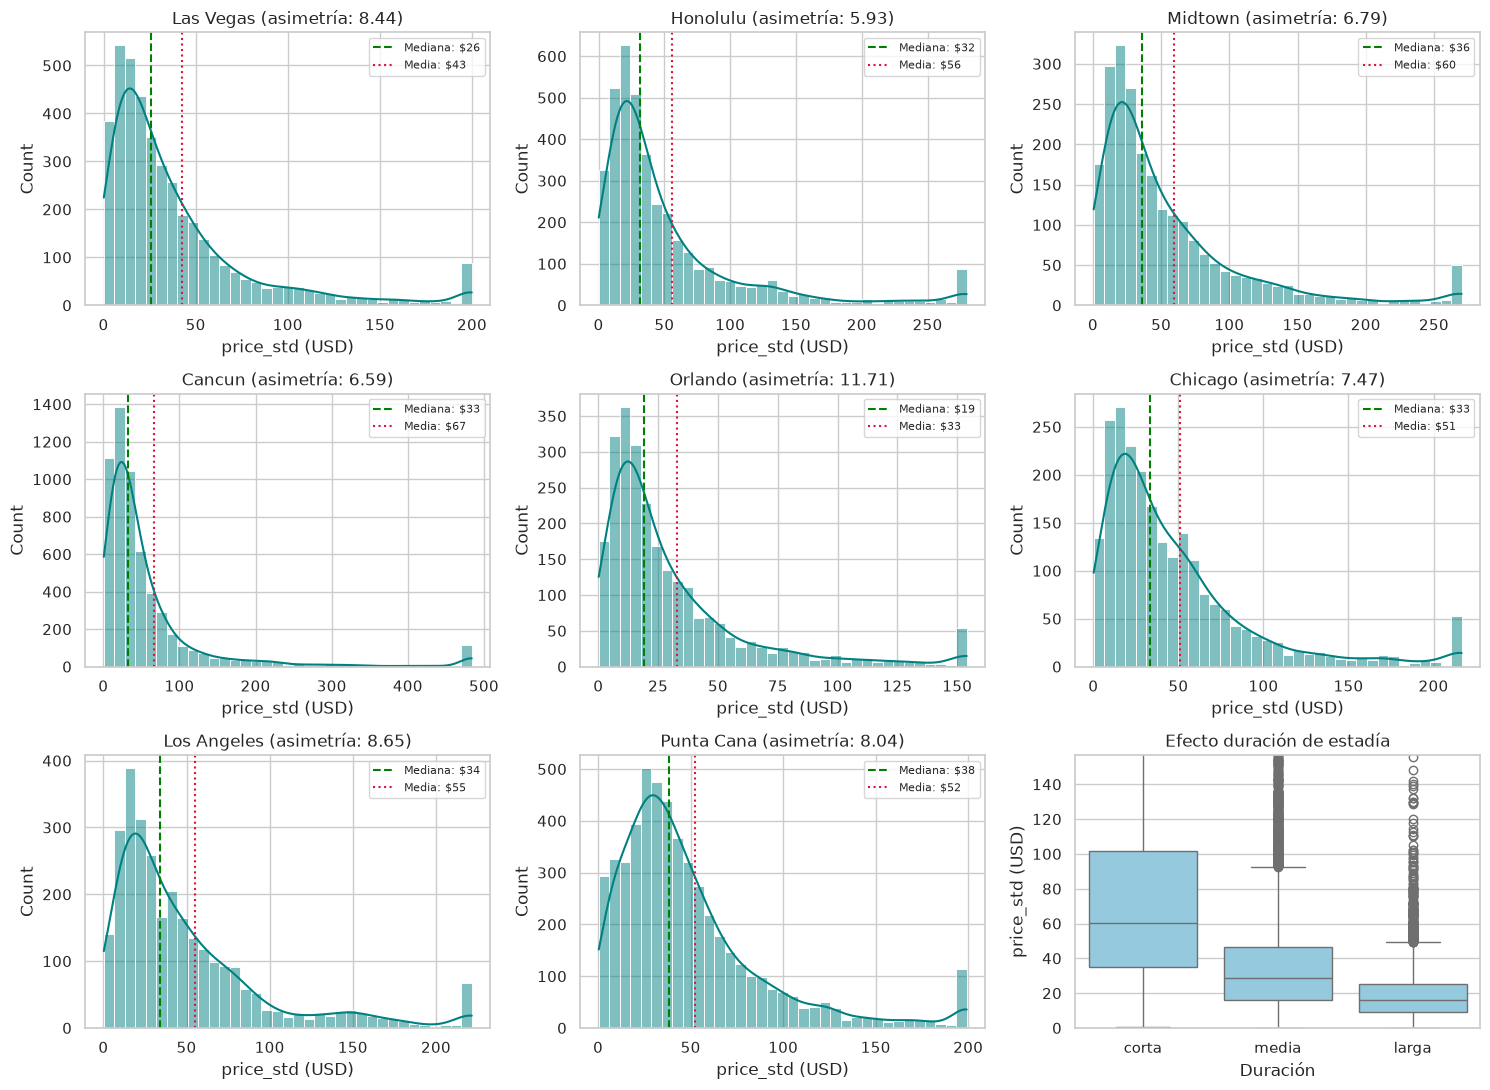

Distribución del Coeficiente de Variación (CV = std/mean) en mercados con N >= 30:
       mean_price  std_price         cv
count   10974.000  10687.000  10687.000
mean       60.120     46.159      0.657
std        52.718     70.067      0.389
min         2.080      0.013      0.002
25%        27.622     13.465      0.437
50%        48.706     27.266      0.578
75%        74.556     49.100      0.748
max       749.633    992.179      3.885


In [7]:
# 1. Distribución de precios en los destinos principales
top_dests = df.groupby("destination_name")["count_repeated"].sum().sort_values(ascending=False).head(8).index.tolist()
df_top = df[df["destination_name"].isin(top_dests)].copy()

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, d in enumerate(top_dests):
    sub = df_top[df_top["destination_name"] == d]
    p_median = sub["price_std"].median()
    p_mean = sub["price_std"].mean()
    sns.histplot(sub["price_std"].clip(upper=sub["price_std"].quantile(0.98)), bins=35, kde=True, ax=axes[i], color="teal")
    axes[i].axvline(p_median, color="green", linestyle="--", label=f"Mediana: ${p_median:.0f}")
    axes[i].axvline(p_mean, color="crimson", linestyle=":", label=f"Media: ${p_mean:.0f}")
    axes[i].set_title(f"{d} (asimetría: {sub['price_std'].skew():.2f})")
    axes[i].set_xlabel("price_std (USD)")
    axes[i].legend(fontsize=8)

# Gráfico 9: Boxplot por duración de estadía
sns.boxplot(data=df_top, x="stay_duration", y="price_std", order=["corta", "media", "larga"], ax=axes[8], color="skyblue")
axes[8].set_ylim(0, df_top["price_std"].quantile(0.95))
axes[8].set_title("Efecto duración de estadía")
axes[8].set_xlabel("Duración")
axes[8].set_ylabel("price_std (USD)")

plt.tight_layout()
plt.show()

# 2. Resumen del Coeficiente de Variación en mercados confiables
cv_df = tp2_contexts[tp2_contexts["demand_weight"] >= 30].copy()
cv_df["cv"] = cv_df["std_price"] / cv_df["mean_price"]

print("Distribución del Coeficiente de Variación (CV = std/mean) en mercados con N >= 30:")
print(cv_df[["mean_price", "std_price", "cv"]].describe().round(3).to_string())

## 7. Comparativa de estadísticos: evaluando alternativas de detección

Se contrasta la fórmula del docente contra cinco alternativas. La comparación se restringe a observaciones de **mercados con masa estadística ($N \ge 30$)**: con uno o dos registros los percentiles colapsan (si $IQR = 0$, la regla de Tukey marca el 100% de las filas) y los z-scores dependen de la salvaguarda, así que incluir esos mercados mediría ruido y no calidad de detección.

1. **Enfoque del Docente — Z-Score Gaussiano ($z < -1.0$)**:
   $$z = \frac{\text{price\_std} - \mu_{\text{contexto}}}{\sigma_{\text{contexto}}}$$
   Con la salvaguarda de `auxiliary_functions.py`: si $\sigma \le 0$, se usa $\sigma = \max(0.10 \times \mu, 5.0)$ para evitar divisiones por cero.
   *Limitación detectada*: en mercados con hoteles de lujo, $\sigma$ se infla y tarifas muy baratas no llegan a $z < -1.0$ (falsos negativos).

2. **Alternativa 1 — Z-Score Log-Normal ($z_{\log} < -1.0$)**:
   Los precios hoteleros son estrictamente positivos y crecen de forma multiplicativa; la transformación $y = \ln(\text{price\_std})$ simetriza la distribución:
   $$z_{\log} = \frac{\ln(\text{price\_std}) - \mu_{\ln}}{\sigma_{\ln}}$$
   *Ventaja*: los hoteles caros dejan de inflar la varianza y la dispersión se mide en términos proporcionales.

3. **Alternativa 2 — Descuento Relativo sobre Mediana (ahorro $\ge 30\%$)**:
   $$\text{descuento} = 1 - \frac{\text{price\_std}}{\text{mediana}_{\text{contexto}}} \ge 0.30$$
   *Ventaja*: se comunica directo al usuario ("al menos 30% de ahorro frente a la tarifa típica de esa fecha").

4. **Alternativa 3 — Detector Híbrido ($z_{\log} < -1.0$ y ahorro $\ge 20\%$)**:
   Exige significancia estadística y un ahorro mínimo del 20%, filtrando el sesgo de varianza y los descuentos de centavos.

5. **Alternativas 4 y 5 — Percentil 10 contextual ($p_{10}$) y límite inferior de Tukey ($Q_1 - 1.5 \times IQR$)**:
   Cortes de referencia no paramétricos.

Observaciones en mercados confiables (N >= 30): 118,160 de 297,363 (39.7%)
Observaciones evaluadas: 118,160
Comparativa de criterios de detección sobre el dataset curado:
                                                     método  filas_detectadas  pct_detectado  precio_medio_usd
                     Z-Score Gaussiano (z < -1.0) [Docente]             10561       8.937881         15.807292
                    Z-Score Good Price (z < -0.5) [Docente]             37107      31.404028         24.842568
          Z-Score Log-Normal (z_log < -1.0) [Alternativa 1]             16837      14.249323         16.327025
Detector Híbrido (z_log < -1.0 & Ahorro >= 20%) [Propuesta]             16684      14.119838         16.160131
                Descuento >= 30% s/ Mediana [Alternativa 2]             30083      25.459546         21.177476
                   Percentil 10 contextual [No paramétrico]             16924      14.322952         18.730752
                 IQR inferior (Q1 - 1.5·IQR) [Outlie

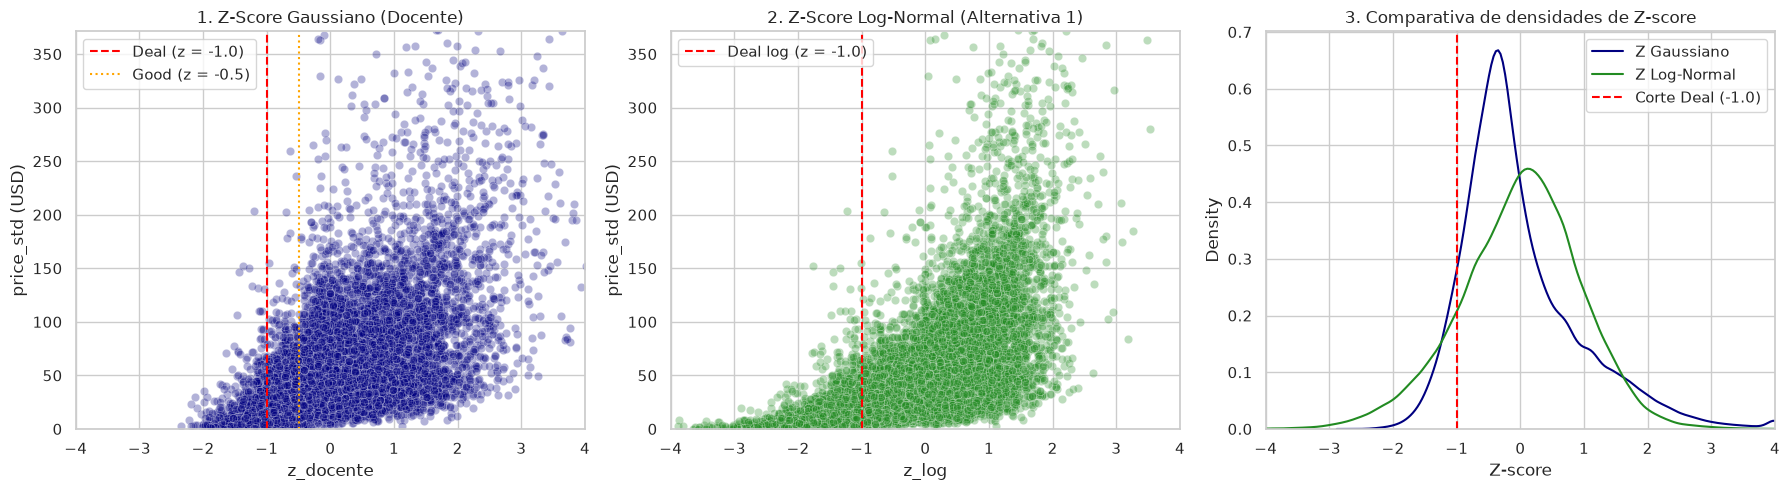

In [8]:
stats_to_merge = tp2_contexts[[
    "destination_final", "month", "week_in_month", "stay_duration",
    "mean_price", "std_price", "median_price", "mean_log_price", "std_log_price",
    "p10", "p25", "p75", "q_lo"
]].copy()

# La comparativa solo es válida en mercados con masa estadística (N >= 30).
# En mercados de 1-2 registros los percentiles colapsan (p25 = p50 = p75, IQR = 0)
# y los z-scores dependen de la salvaguarda: ahí se mide ruido, no calidad de detección.
# Los mercados sin masa se resuelven con la cascada de rescate (sección 8).
solid_keys = tp2_contexts.loc[tp2_contexts["demand_weight"] >= 30, context_cols].drop_duplicates()
df_solid = df.merge(solid_keys, on=context_cols, how="inner")

sample_eval = df_solid.sample(n=min(150_000, len(df_solid)), random_state=42).copy()
eval_df = sample_eval.merge(stats_to_merge, on=context_cols, how="left")

print(f"Observaciones en mercados confiables (N >= 30): {len(df_solid):,} de {len(df):,} "
      f"({100.0 * len(df_solid) / len(df):.1f}%)")
print(f"Observaciones evaluadas: {len(eval_df):,}")

# 1. Z-Score Gaussiano del Docente con salvaguarda
std_safe = eval_df["std_price"].copy()
zero_std = (std_safe <= 0) | (std_safe.isna())
std_safe[zero_std] = (eval_df.loc[zero_std, "mean_price"] * 0.10).clip(lower=5.0)

eval_df["z_docente"] = (eval_df["price_std"] - eval_df["mean_price"]) / std_safe
eval_df["clasificacion_docente"] = eval_df["z_docente"].apply(af.classify_deal)
eval_df["flag_deal_docente"] = eval_df["z_docente"] < config.THRESHOLDS["deal"]         # z < -1.0
eval_df["flag_good_docente"] = eval_df["z_docente"] < config.THRESHOLDS["good_price"]   # z < -0.5

# 2. Alternativa 1: Z-Score Log-Normal
std_log_safe = eval_df["std_log_price"].copy()
zero_std_log = (std_log_safe <= 0) | (std_log_safe.isna())
std_log_safe[zero_std_log] = 0.20  # Salvaguarda en escala logarítmica (~20% de dispersión)

eval_df["z_log"] = (eval_df["log_price_std"] - eval_df["mean_log_price"]) / std_log_safe
eval_df["flag_deal_log"] = eval_df["z_log"] < -1.0

# 3. Alternativa 2: Descuento Relativo sobre la Mediana (>= 30% de ahorro)
eval_df["discount_ratio"] = 1.0 - (eval_df["price_std"] / eval_df["median_price"].clip(lower=1.0))
eval_df["flag_discount_30pct"] = eval_df["discount_ratio"] >= 0.30

# 4. Alternativa 3: Detector Híbrido (z_log < -1.0 Y descuento >= 20%)
eval_df["flag_deal_hibrido"] = (eval_df["z_log"] < -1.0) & (eval_df["discount_ratio"] >= 0.20)

# 5. Percentil 10 y Tukey IQR
eval_df["flag_p10"] = eval_df["price_std"] <= eval_df["p10"]
eval_df["flag_iqr"] = eval_df["price_std"] <= eval_df["q_lo"]

# Comparativa numérica entre métodos
methods_summary = pd.DataFrame({
    "método": [
        f"Z-Score Gaussiano (z < {config.THRESHOLDS['deal']}) [Docente]",
        f"Z-Score Good Price (z < {config.THRESHOLDS['good_price']}) [Docente]",
        "Z-Score Log-Normal (z_log < -1.0) [Alternativa 1]",
        "Detector Híbrido (z_log < -1.0 & Ahorro >= 20%) [Propuesta]",
        "Descuento >= 30% s/ Mediana [Alternativa 2]",
        "Percentil 10 contextual [No paramétrico]",
        "IQR inferior (Q1 - 1.5·IQR) [Outlier puro]"
    ],
    "filas_detectadas": [
        eval_df["flag_deal_docente"].sum(),
        eval_df["flag_good_docente"].sum(),
        eval_df["flag_deal_log"].sum(),
        eval_df["flag_deal_hibrido"].sum(),
        eval_df["flag_discount_30pct"].sum(),
        eval_df["flag_p10"].sum(),
        eval_df["flag_iqr"].sum()
    ],
    "pct_detectado": [
        100.0 * eval_df["flag_deal_docente"].mean(),
        100.0 * eval_df["flag_good_docente"].mean(),
        100.0 * eval_df["flag_deal_log"].mean(),
        100.0 * eval_df["flag_deal_hibrido"].mean(),
        100.0 * eval_df["flag_discount_30pct"].mean(),
        100.0 * eval_df["flag_p10"].mean(),
        100.0 * eval_df["flag_iqr"].mean()
    ],
    "precio_medio_usd": [
        eval_df.loc[eval_df["flag_deal_docente"], "price_std"].mean(),
        eval_df.loc[eval_df["flag_good_docente"], "price_std"].mean(),
        eval_df.loc[eval_df["flag_deal_log"], "price_std"].mean(),
        eval_df.loc[eval_df["flag_deal_hibrido"], "price_std"].mean(),
        eval_df.loc[eval_df["flag_discount_30pct"], "price_std"].mean(),
        eval_df.loc[eval_df["flag_p10"], "price_std"].mean(),
        eval_df.loc[eval_df["flag_iqr"], "price_std"].mean()
    ]
})
print("Comparativa de criterios de detección sobre el dataset curado:")
print(methods_summary.to_string(index=False))

# Matriz de correlación entre criterios
flag_cols = ["flag_deal_docente", "flag_deal_log", "flag_deal_hibrido", "flag_discount_30pct", "flag_p10", "flag_iqr"]
corr = eval_df[flag_cols].astype(float).corr()
print("\nCorrelación entre criterios de detección:")
print(corr.round(3).to_string())

# Visualización comparativa: Z-score Gaussiano vs Log-Normal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_plot = eval_df.sample(n=min(15_000, len(eval_df)), random_state=42)

# Panel 1: Z-score Gaussiano vs price_std
sns.scatterplot(data=sample_plot, x="z_docente", y="price_std", alpha=0.3, ax=axes[0], color="navy")
axes[0].axvline(config.THRESHOLDS["deal"], color="red", linestyle="--", label=f"Deal (z = {config.THRESHOLDS['deal']})")
axes[0].axvline(config.THRESHOLDS["good_price"], color="orange", linestyle=":", label=f"Good (z = {config.THRESHOLDS['good_price']})")
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(0, eval_df["price_std"].quantile(0.99))
axes[0].set_title("1. Z-Score Gaussiano (Docente)")
axes[0].set_xlabel("z_docente")
axes[0].set_ylabel("price_std (USD)")
axes[0].legend()

# Panel 2: Z-score Log-Normal vs price_std
sns.scatterplot(data=sample_plot, x="z_log", y="price_std", alpha=0.3, ax=axes[1], color="forestgreen")
axes[1].axvline(-1.0, color="red", linestyle="--", label="Deal log (z = -1.0)")
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(0, eval_df["price_std"].quantile(0.99))
axes[1].set_title("2. Z-Score Log-Normal (Alternativa 1)")
axes[1].set_xlabel("z_log")
axes[1].set_ylabel("price_std (USD)")
axes[1].legend()

# Panel 3: Distribución comparativa de ambos Z-scores
sns.kdeplot(eval_df["z_docente"].clip(-4, 4), ax=axes[2], color="navy", label="Z Gaussiano", bw_adjust=1.2)
sns.kdeplot(eval_df["z_log"].clip(-4, 4), ax=axes[2], color="forestgreen", label="Z Log-Normal", bw_adjust=1.2)
axes[2].axvline(-1.0, color="red", linestyle="--", label="Corte Deal (-1.0)")
axes[2].set_xlim(-4, 4)
axes[2].set_title("3. Comparativa de densidades de Z-score")
axes[2].set_xlabel("Z-score")
axes[2].legend()

plt.tight_layout()
plt.show()

### Balance comparativo: ¿por qué no quedarse solo con la fórmula lineal?

Del contraste salen tres conclusiones:

1. **El Z-Score Gaussiano lineal subestima ofertas en plazas heterogéneas:**
   En destinos como Las Vegas, Miami o Cancún conviven hoteles económicos con resorts de más de 800 USD. Esa dispersión infla $\sigma$: una tarifa de 25 USD en un contexto con $\mu = 90$ y $\sigma = 75$ da $z = (25 - 90)/75 = -0.87$, apenas un "Good Price". La oferta se pierde.

2. **El Z-Score Log-Normal mide la distancia en proporciones:**
   En escala logarítmica, 25 USD queda a $\ln(25) - \ln(90) = -1.28$ del centro; con el desvío logarítmico mediano de estos mercados ($\sigma_{\ln} \approx 0.62$) eso equivale a $z_{\log} \approx -2$: oferta detectada. Sobre los mercados confiables, el detector log-normal marca el **14.2%** de las tarifas a un precio medio de 16.33 USD, frente al **8.9%** del gaussiano (15.81 USD): detecta un 60% más de ofertas sin elevar el precio medio de lo encontrado.

3. **El filtro de descuento sobre mediana garantiza relevancia económica:**
   En mercados de tarifas casi fijas (hoteles de aeropuerto a 40-42 USD), un precio de 39 USD puede dar $z_{\log} < -1.0$ con un ahorro de apenas 2 USD. La cota del 20% sobre la mediana elimina esos casos y cuesta poco: baja la detección de 14.25% a 14.12%.

Las dos referencias no paramétricas quedan descartadas: el percentil 10 etiqueta una cuota fija (~14%) aun en mercados homogéneos, y la cerca inferior de Tukey casi no se activa (0.9%): en distribuciones con sesgo positivo, $Q_1 - 1.5 \times IQR$ suele caer por debajo del precio mínimo del mercado.

## 8. Decisiones metodológicas para el TP3

Cuatro decisiones para el clasificador del TP3:

1. **Métrica base:** `price_std` (USD por habitación-noche-persona). Las tarifas brutas mezclan tamaño de grupo con precio.

2. **Segmentación de mercado:**
   $$\text{Mercado} = \text{destination\_final} \times \text{month} \times \text{week\_in\_month} \times \text{stay\_duration}$$
   Retiene el 77% de la demanda en celdas con $N \ge 30$.

3. **Detector adoptado (ground truth para Machine Learning):**
   $$\mathbf{\text{is\_deal}} = (z_{\log} < -1.0) \;\land\; \left(1 - \frac{\text{price\_std}}{\text{mediana}_{\text{contexto}}} \ge 0.20\right)$$
   - Frente al Z-Score lineal del docente: los hoteles de lujo no inflan la varianza y desaparecen los falsos negativos en plazas heterogéneas (14.2% de detección contra 8.9%).
   - Frente al Percentil 10: no fuerza una cuota fija en mercados homogéneos; solo etiqueta cuando el precio se aleja de la distribución.
   - La cota sobre la mediana asegura un ahorro mínimo del 20% para el viajero.

4. **Rol en el pipeline del TP3:**
   - La regla define la etiqueta binaria `is_deal` sobre el dataset curado.
   - Se entrenarán clasificadores (LightGBM, XGBoost, Random Forest) con las variables de contexto (`day_of_week`, `month`, `stay_duration`, `price_bucket`, `destination_final`) para comparar el Machine Learning contra la heurística estadística.
   - En celdas con $N < 30$ se mantiene la cascada de rescate:
     $$\text{Semana exacta} \;\longrightarrow\; \text{Mes completo} \;\longrightarrow\; \text{Destino global}$$